# Intensity Transformations on Runway Image

This applies various intensity transformations to runway.png:
- (a) Gamma correction with γ = 0.5
- (b) Gamma correction with γ = 2.0
- (c) Contrast Stretching (linear piecewise transformation)

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set up matplotlib for better display
plt.style.use('default')
%matplotlib inline


## Load and Display Original Image

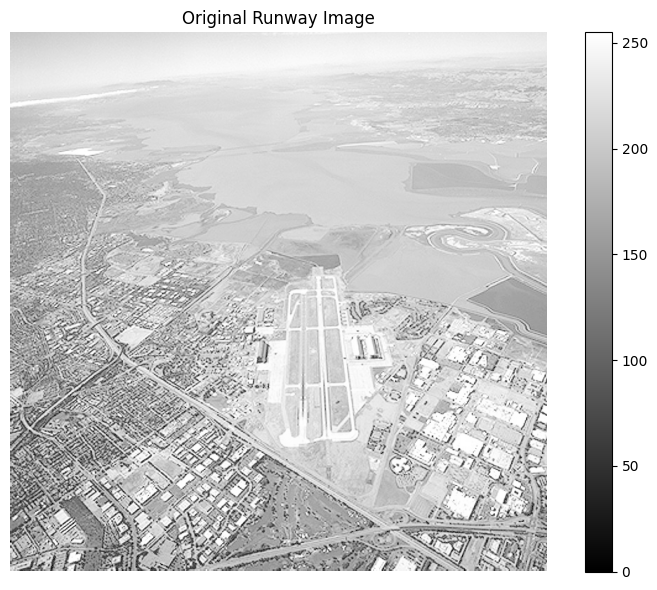

Image shape: (769, 765)
Data type: uint8
Intensity range: [0, 255]


In [2]:
# Load the runway image
img = cv2.imread('runway.png', cv2.IMREAD_GRAYSCALE)

# Display original image
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Runway Image')
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"Image shape: {img.shape}")
print(f"Data type: {img.dtype}")
print(f"Intensity range: [{img.min()}, {img.max()}]")


## (a) Gamma Correction with 0.5

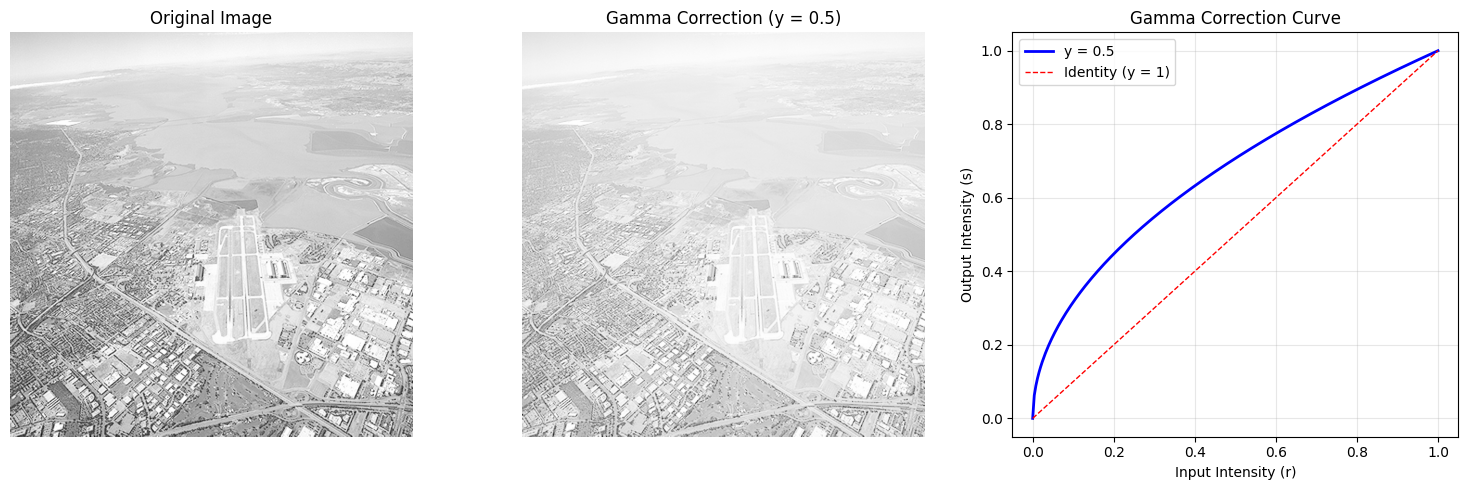

Gamma = 0.5: Brightens the image


In [8]:
# Gamma correction with gamma = 0.5
gamma_05 = 0.5

# Normalize image to [0, 1]
img_normalized = img / 255.0

# Apply gamma correction
img_gamma_05 = np.power(img_normalized, gamma_05)

# Convert back to [0, 255]
img_gamma_05_uint8 = np.uint8(img_gamma_05 * 255)

# Display result
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gamma_05_uint8, cmap='gray')
plt.title(f'Gamma Correction (y = {gamma_05})')
plt.axis('off')

plt.subplot(1, 3, 3)
# Plot the transformation curve
r = np.linspace(0, 1, 256)
s = np.power(r, gamma_05)
plt.plot(r, s, 'b-', linewidth=2, label=f'y = {gamma_05}')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Identity (y = 1)')
plt.xlabel('Input Intensity (r)')
plt.ylabel('Output Intensity (s)')
plt.title('Gamma Correction Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Gamma = {gamma_05}: Brightens the image")


## (b) Gamma Correction with 2.0

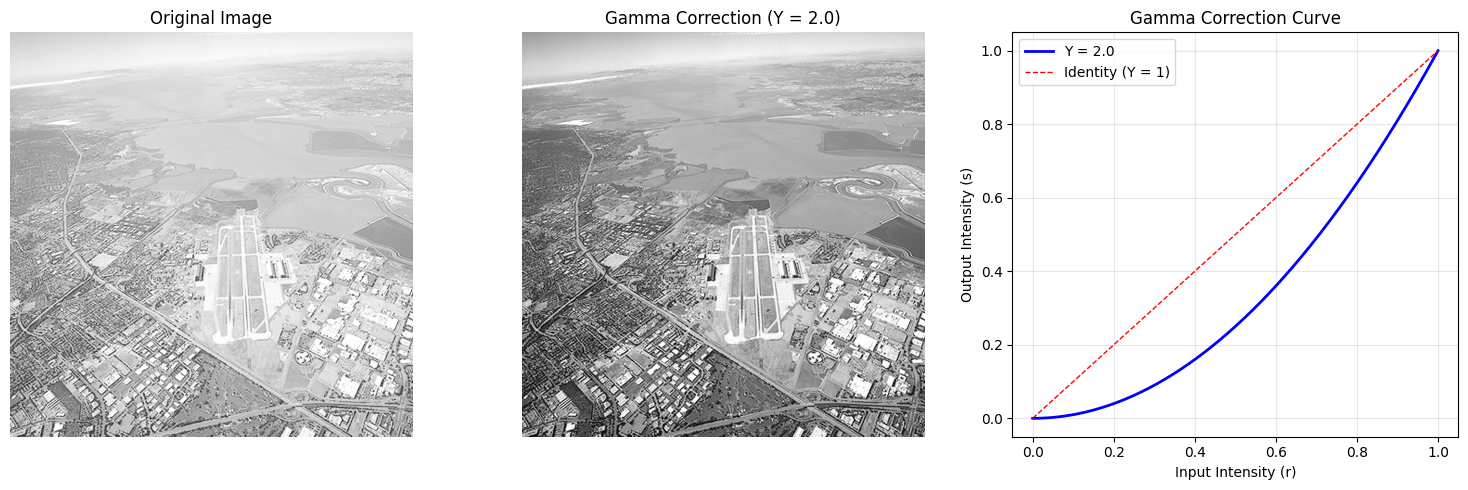

Gamma = 2.0: Darkens the image


In [9]:
# Gamma correction with gamma = 2.0
gamma_2 = 2.0

# Apply gamma correction (image already normalized)
img_gamma_2 = np.power(img_normalized, gamma_2)

# Convert back to [0, 255]
img_gamma_2_uint8 = np.uint8(img_gamma_2 * 255)

# Display result
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gamma_2_uint8, cmap='gray')
plt.title(f'Gamma Correction (Y = {gamma_2})')
plt.axis('off')

plt.subplot(1, 3, 3)
# Plot the transformation curve
r = np.linspace(0, 1, 256)
s = np.power(r, gamma_2)
plt.plot(r, s, 'b-', linewidth=2, label=f'Y = {gamma_2}')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Identity (Y = 1)')
plt.xlabel('Input Intensity (r)')
plt.ylabel('Output Intensity (s)')
plt.title('Gamma Correction Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Gamma = {gamma_2}: Darkens the image")


## (c) Contrast Stretching - Linear Piecewise Transformation

In [10]:
# Define contrast stretching parameters
r1 = 0.2
r2 = 0.8

# Define the piecewise linear transformation function
def contrast_stretching(r, r1, r2):
    s = np.zeros_like(r)
    
    # Apply piecewise transformation
    # Region 1: r < r1 → s = 0
    s[r < r1] = 0
    
    # Region 2: r1 <= r <= r2 → s = (r - r1) / (r2 - r1)
    mask = (r >= r1) & (r <= r2)
    s[mask] = (r[mask] - r1) / (r2 - r1)
    
    # Region 3: r > r2 → s = 1
    s[r > r2] = 1
    
    return s

# Apply contrast stretching to the image (already normalized)
img_contrast_stretched = contrast_stretching(img_normalized, r1, r2)

# Convert back to [0, 255]
img_contrast_stretched_uint8 = np.uint8(img_contrast_stretched * 255)

print(f"Contrast stretching applied with r1 = {r1}, r2 = {r2}")


Contrast stretching applied with r1 = 0.2, r2 = 0.8


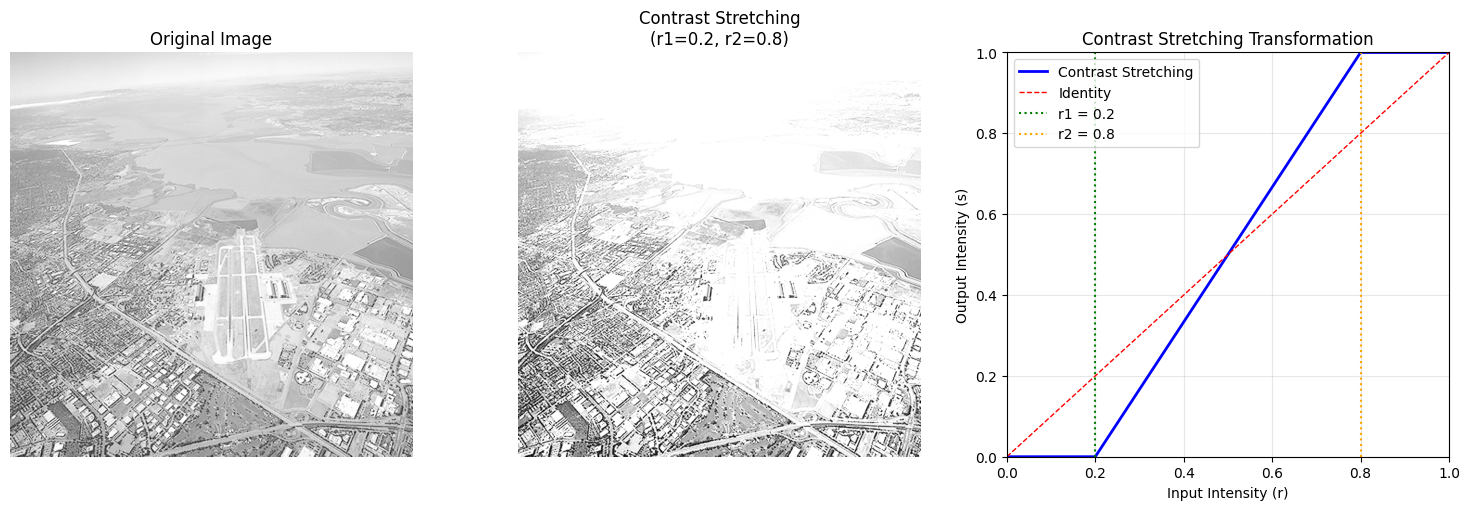

Contrast stretching enhances the contrast by mapping [r1, r2] to [0, 1]


In [11]:
# Display result
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_contrast_stretched_uint8, cmap='gray')
plt.title(f'Contrast Stretching\n(r1={r1}, r2={r2})')
plt.axis('off')

plt.subplot(1, 3, 3)
# Plot the transformation curve
r = np.linspace(0, 1, 1000)
s = contrast_stretching(r, r1, r2)
plt.plot(r, s, 'b-', linewidth=2, label='Contrast Stretching')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Identity')
plt.axvline(x=r1, color='g', linestyle=':', linewidth=1.5, label=f'r1 = {r1}')
plt.axvline(x=r2, color='orange', linestyle=':', linewidth=1.5, label=f'r2 = {r2}')
plt.xlabel('Input Intensity (r)')
plt.ylabel('Output Intensity (s)')
plt.title('Contrast Stretching Transformation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"Contrast stretching enhances the contrast by mapping [r1, r2] to [0, 1]")
